# Анализ данных Flood Prediction Factors

## Обзор датасета для соревнования Kaggle

Этот ноутбук содержит анализ данных для прогнозирования вероятности наводнений.


In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Настройка стиля визуализаций
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


## 1. Загрузка данных


In [2]:
# Загрузка данных
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
sample_submission = pd.read_csv('data/sample_submission.csv')

print(f"Размер train: {train.shape}")
print(f"Размер test: {test.shape}")
print(f"Размер sample_submission: {sample_submission.shape}")


Размер train: (1117957, 22)
Размер test: (745305, 21)
Размер sample_submission: (745305, 2)


## 2. Первичный анализ данных


In [3]:
# Просмотр первых строк
print("Первые строки train данных:")
display(train.head(10))


Первые строки train данных:


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415
5,5,5,4,1,4,2,4,6,6,7,...,3,5,5,4,4,6,8,3,2,0.440
6,6,8,3,1,2,3,7,3,4,6,...,2,5,6,4,5,6,3,4,6,0.460
7,7,6,6,5,7,5,5,3,5,5,...,5,3,5,5,8,6,8,5,6,0.595
8,8,5,2,8,5,4,5,2,4,5,...,9,2,7,3,4,6,4,5,5,0.505
9,9,4,2,3,5,8,6,5,5,7,...,6,3,3,4,4,3,3,5,6,0.455


In [4]:
# Информация о данных
print("\nИнформация о датасете:")
train.info()



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPrepare

In [5]:
# Статистика по признакам
print("\nСтатистическое описание:")
display(train.describe())



Статистическое описание:


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,...,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06
mean,5.589780e+05,4.921450e+00,4.926671e+00,4.955322e+00,4.942240e+00,4.942517e+00,4.934093e+00,4.955878e+00,4.927791e+00,4.942619e+00,...,4.946893e+00,4.953999e+00,4.931376e+00,4.929032e+00,4.925907e+00,4.927520e+00,4.950859e+00,4.940587e+00,4.939004e+00,5.044803e-01
std,3.227265e+05,2.056387e+00,2.093879e+00,2.072186e+00,2.051689e+00,2.083391e+00,2.057742e+00,2.083063e+00,2.065992e+00,2.068545e+00,...,2.072333e+00,2.088899e+00,2.078287e+00,2.082395e+00,2.064813e+00,2.074176e+00,2.068696e+00,2.081123e+00,2.090350e+00,5.102610e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.850000e-01
25%,2.794890e+05,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,...,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.700000e-01
50%,5.589780e+05,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.050000e-01
75%,8.384670e+05,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,5.400000e-01
max,1.117956e+06,1.600000e+01,1.800000e+01,1.600000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.600000e+01,...,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.700000e+01,1.800000e+01,1.900000e+01,1.600000e+01,1.600000e+01,7.250000e-01


In [6]:
# Проверка пропущенных значений
missing_values = train.isnull().sum()
print("\nПропущенные значения:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Пропущенных значений нет")



Пропущенные значения:
Пропущенных значений нет


## 3. Анализ целевой переменной (FloodProbability)


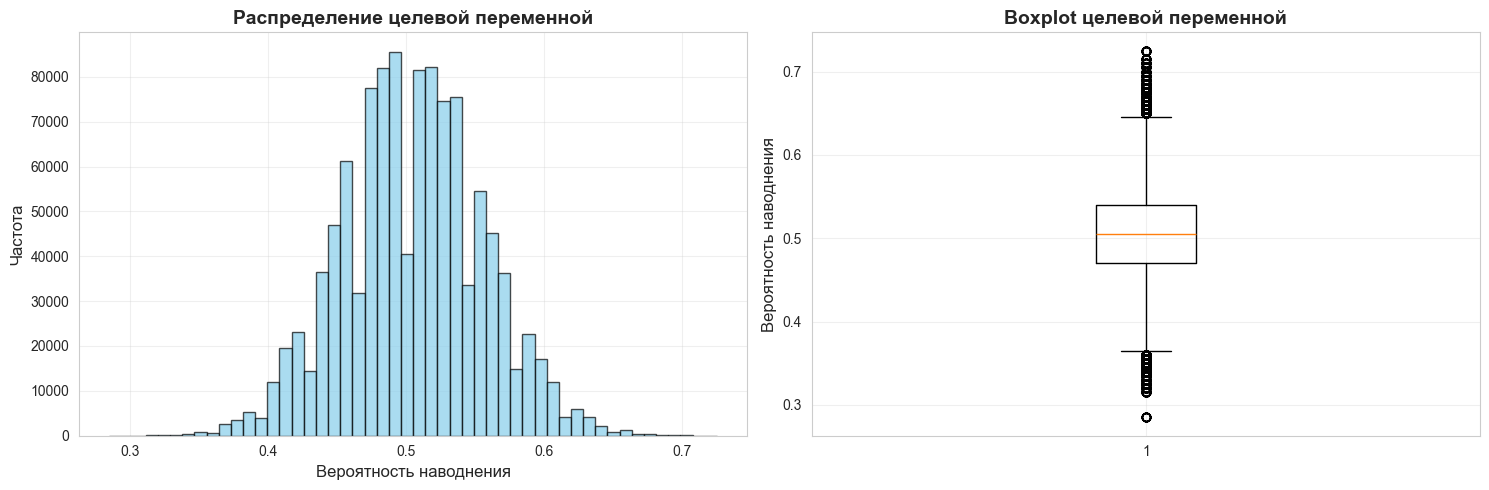


Статистика FloodProbability:
Среднее: 0.5045
Медиана: 0.5050
Стандартное отклонение: 0.0510
Минимум: 0.2850
Максимум: 0.7250


In [7]:
# Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма
axes[0].hist(train['FloodProbability'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Вероятность наводнения', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].set_title('Распределение целевой переменной', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(train['FloodProbability'], vert=True)
axes[1].set_ylabel('Вероятность наводнения', fontsize=12)
axes[1].set_title('Boxplot целевой переменной', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nСтатистика FloodProbability:")
print(f"Среднее: {train['FloodProbability'].mean():.4f}")
print(f"Медиана: {train['FloodProbability'].median():.4f}")
print(f"Стандартное отклонение: {train['FloodProbability'].std():.4f}")
print(f"Минимум: {train['FloodProbability'].min():.4f}")
print(f"Максимум: {train['FloodProbability'].max():.4f}")


## 4. Анализ признаков


In [8]:
# Список признаков (исключая id и целевую переменную)
features = [col for col in train.columns if col not in ['id', 'FloodProbability']]
print(f"Количество признаков: {len(features)}")
print(f"\nСписок признаков:\n{features}")


Количество признаков: 20

Список признаков:
['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors']


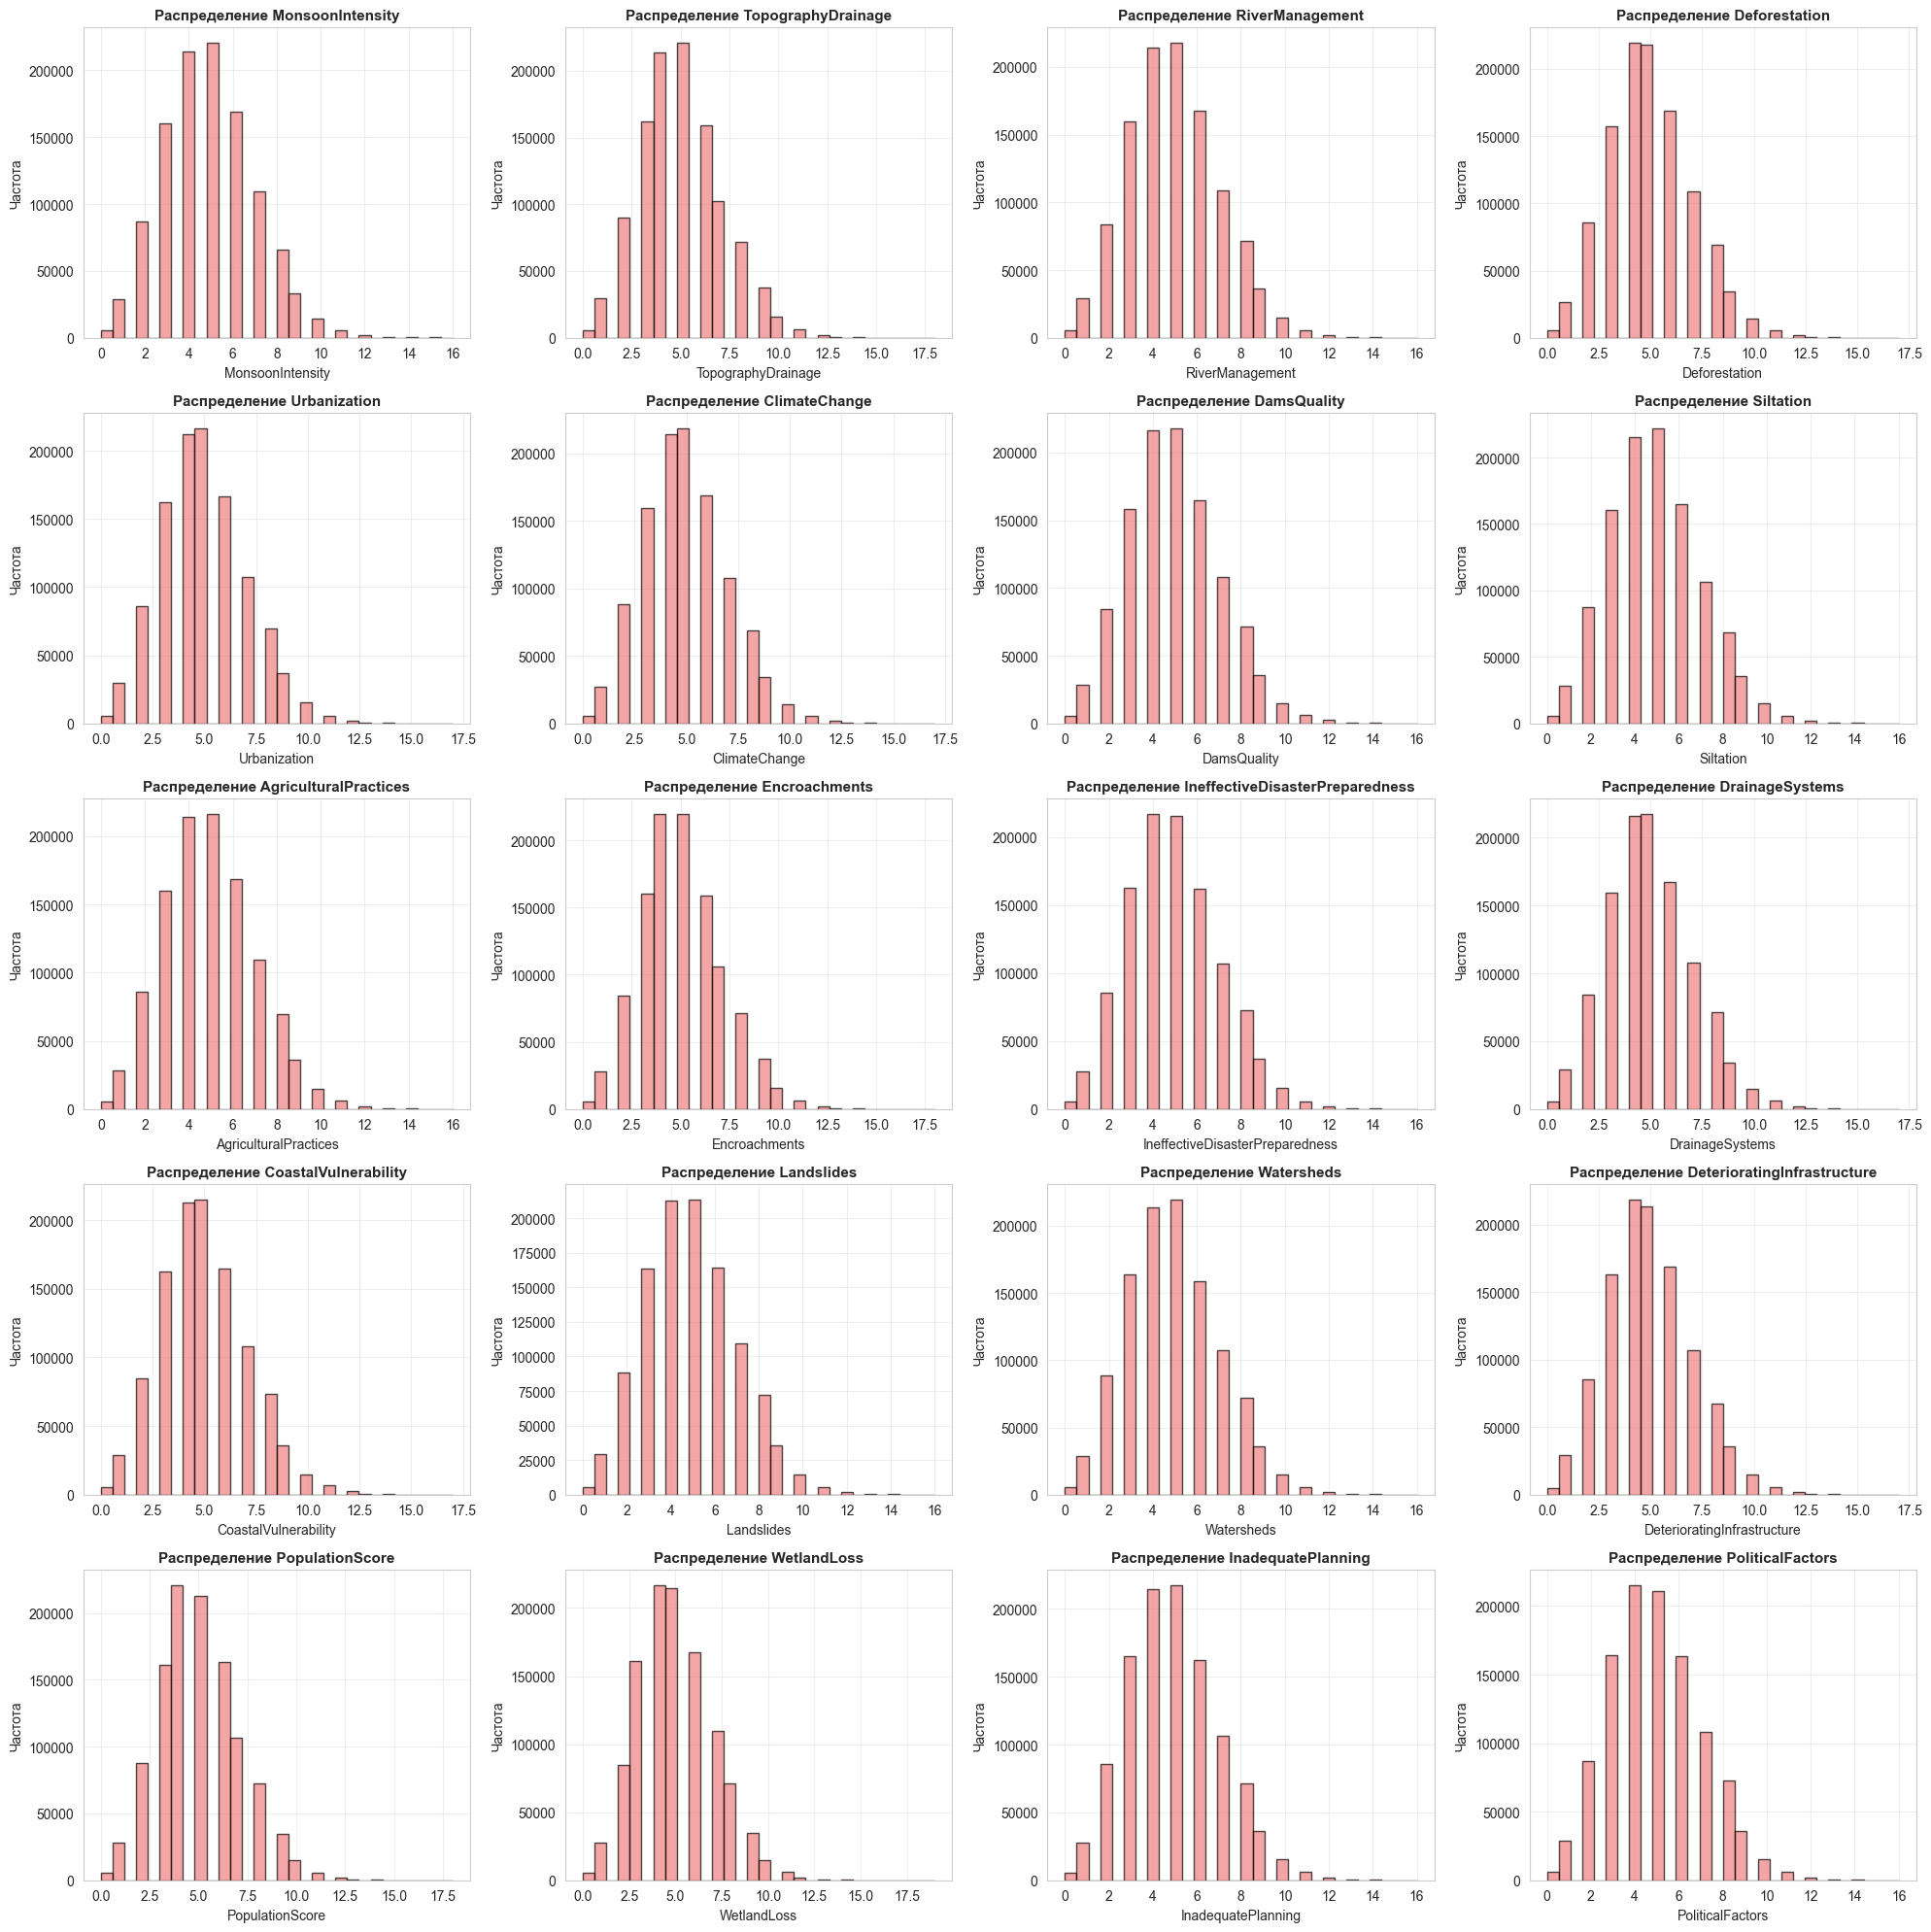

In [9]:
# Распределение всех признаков
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for idx, feature in enumerate(features):
    axes[idx].hist(train[feature], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Частота', fontsize=10)
    axes[idx].set_title(f'Распределение {feature}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
# Статистика по каждому признаку
feature_stats = pd.DataFrame({
    'Признак': features,
    'Мин': [train[f].min() for f in features],
    'Макс': [train[f].max() for f in features],
    'Среднее': [train[f].mean() for f in features],
    'Медиана': [train[f].median() for f in features],
    'Ст.откл': [train[f].std() for f in features]
})

display(feature_stats.style.background_gradient(cmap='YlOrRd', subset=['Среднее', 'Ст.откл']))


,Признак,Мин,Макс,Среднее,Медиана,Ст.откл
0,MonsoonIntensity,0,16,4.921450,5.000000,2.056387
1,TopographyDrainage,0,18,4.926671,5.000000,2.093879
2,RiverManagement,0,16,4.955322,5.000000,2.072186
3,Deforestation,0,17,4.942240,5.000000,2.051689
4,Urbanization,0,17,4.942517,5.000000,2.083391
5,ClimateChange,0,17,4.934093,5.000000,2.057742
6,DamsQuality,0,16,4.955878,5.000000,2.083063
7,Siltation,0,16,4.927791,5.000000,2.065992
8,AgriculturalPractices,0,16,4.942619,5.000000,2.068545
9,Encroachments,0,18,4.949230,5.000000,2.083324


## 5. Корреляционный анализ


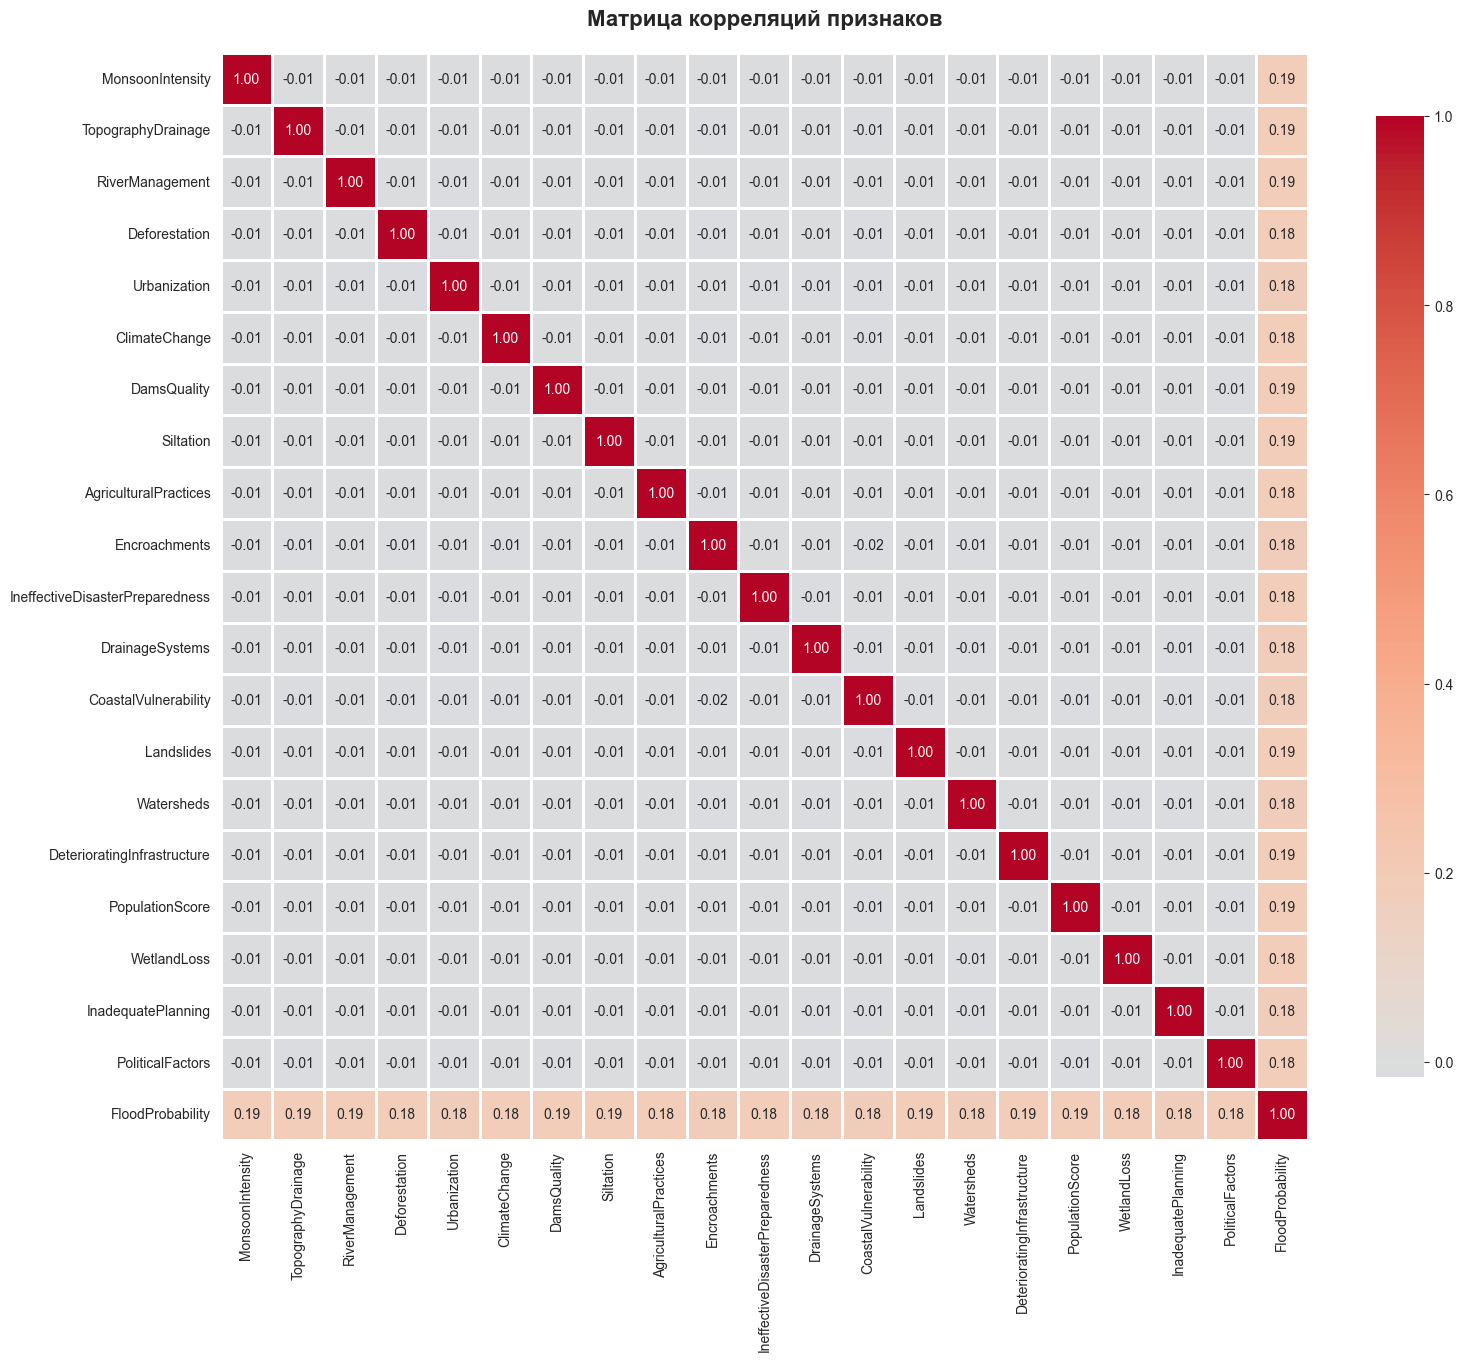

In [11]:
# Матрица корреляций
correlation_matrix = train[features + ['FloodProbability']].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций признаков', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


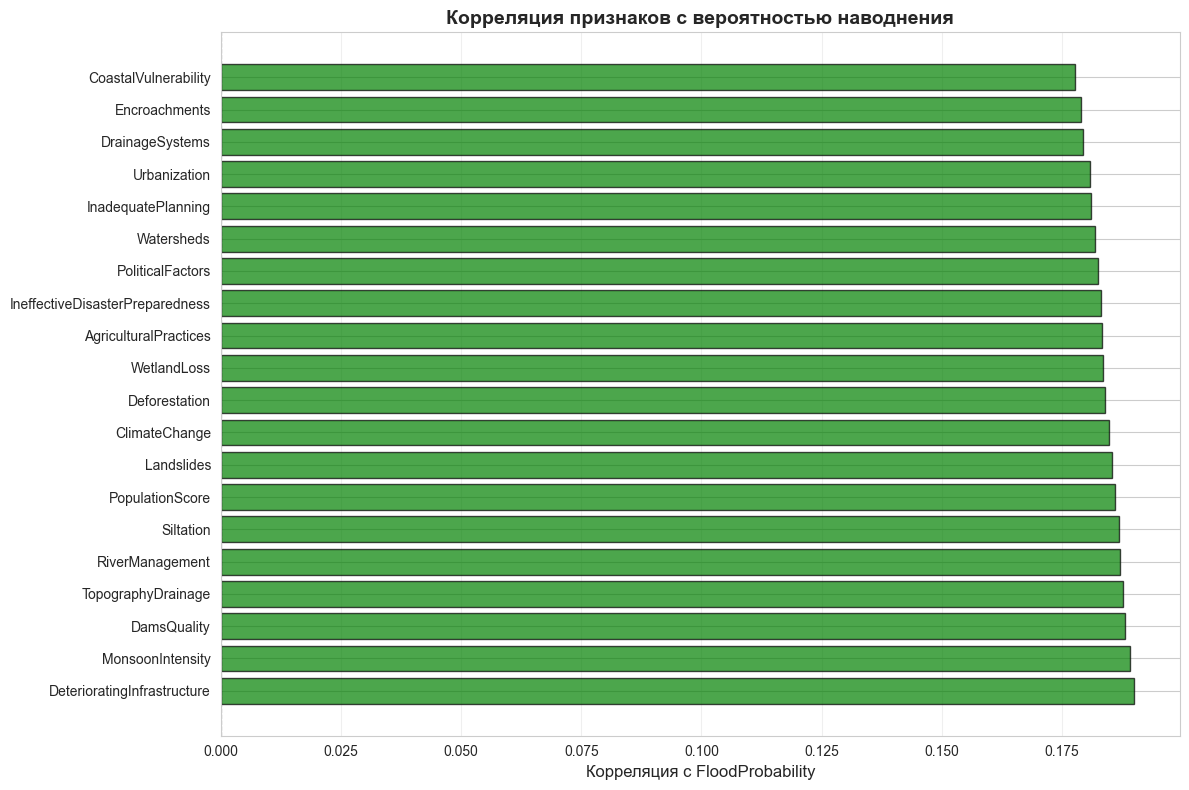


Топ-10 признаков с наибольшей положительной корреляцией:
DeterioratingInfrastructure    0.190007
MonsoonIntensity               0.189098
DamsQuality                    0.187996
TopographyDrainage             0.187635
RiverManagement                0.187131
Siltation                      0.186789
PopulationScore                0.185890
Landslides                     0.185346
ClimateChange                  0.184761
Deforestation                  0.184001
dtype: float64

Топ-10 признаков с наибольшей отрицательной корреляцией:
WetlandLoss                        0.183396
AgriculturalPractices              0.183366
IneffectiveDisasterPreparedness    0.183109
PoliticalFactors                   0.182417
Watersheds                         0.181907
InadequatePlanning                 0.180968
Urbanization                       0.180861
DrainageSystems                    0.179305
Encroachments                      0.178841
CoastalVulnerability               0.177774
dtype: float64


In [12]:
# Корреляция признаков с целевой переменной
target_correlation = train[features].corrwith(train['FloodProbability']).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in target_correlation]
plt.barh(range(len(target_correlation)), target_correlation.values, color=colors, alpha=0.7, edgecolor='black')
plt.yticks(range(len(target_correlation)), target_correlation.index, fontsize=10)
plt.xlabel('Корреляция с FloodProbability', fontsize=12)
plt.title('Корреляция признаков с вероятностью наводнения', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nТоп-10 признаков с наибольшей положительной корреляцией:")
print(target_correlation.head(10))
print("\nТоп-10 признаков с наибольшей отрицательной корреляцией:")
print(target_correlation.tail(10))


## 6. Взаимосвязь признаков с целевой переменной


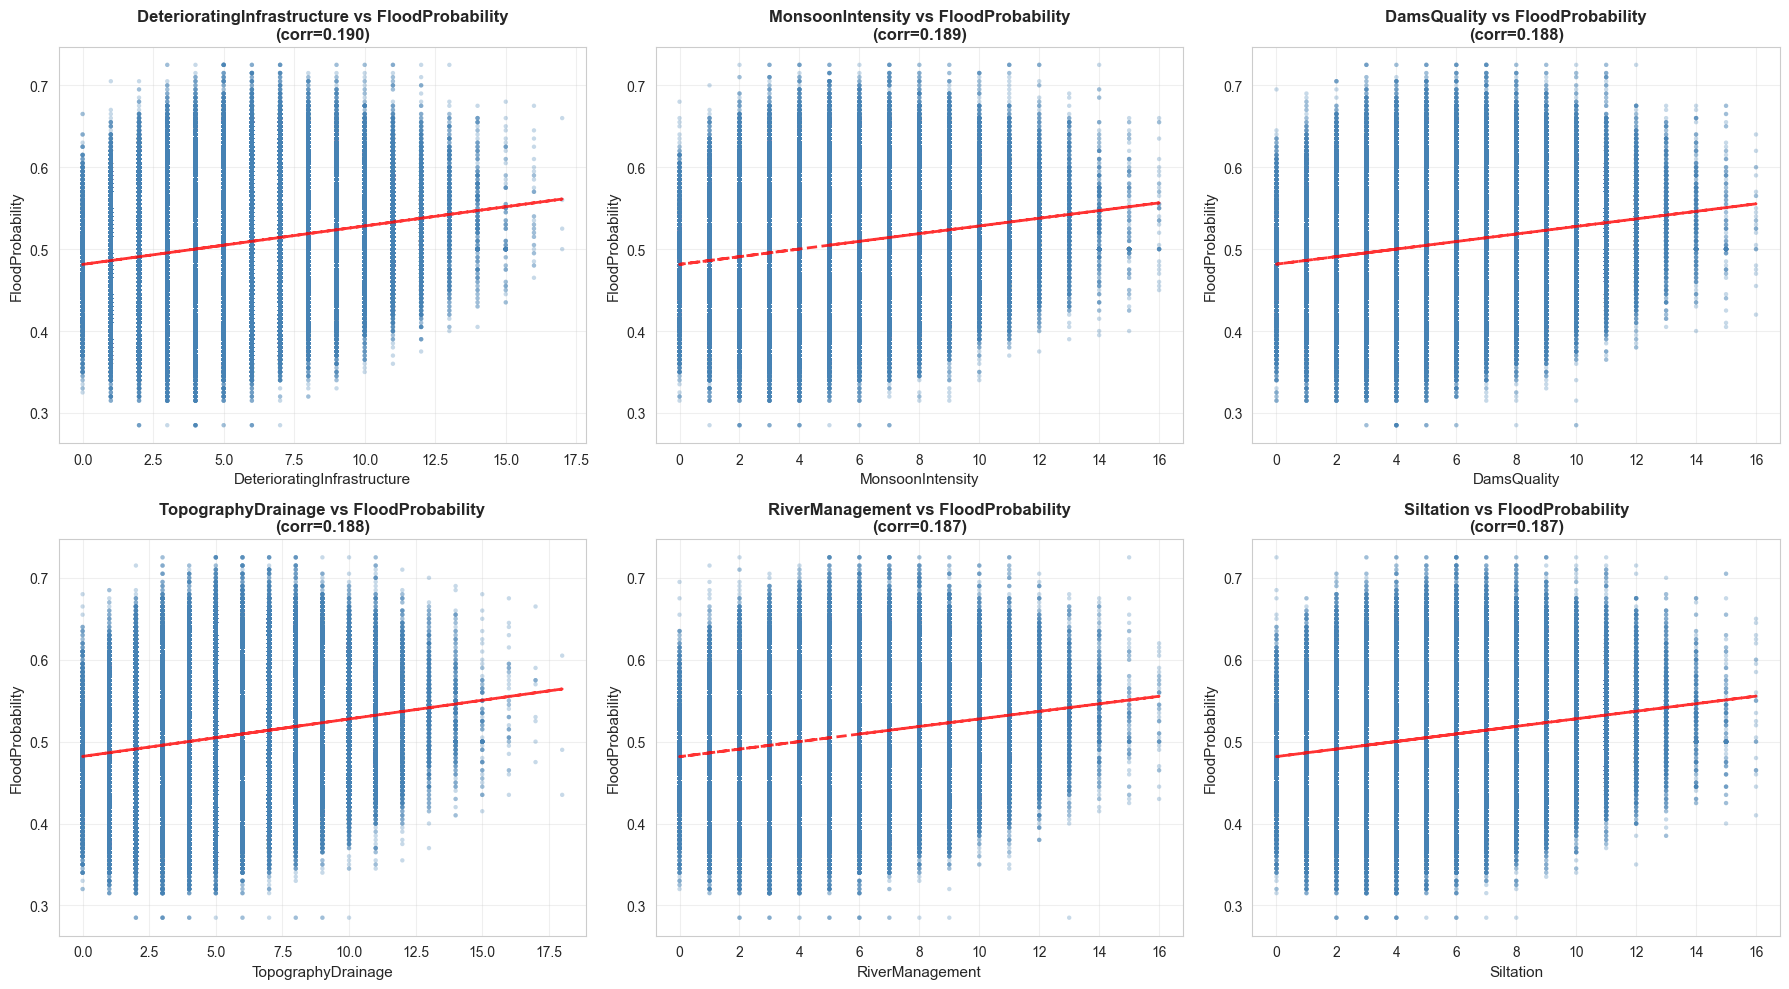

In [13]:
# Scatterplot для топ-6 наиболее коррелированных признаков
top_features = target_correlation.abs().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(train[feature], train['FloodProbability'], 
                     alpha=0.3, s=10, c='steelblue', edgecolors='none')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('FloodProbability', fontsize=11)
    axes[idx].set_title(f'{feature} vs FloodProbability\n(corr={train[feature].corr(train["FloodProbability"]):.3f})', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Добавляем линию тренда
    z = np.polyfit(train[feature], train['FloodProbability'], 1)
    p = np.poly1d(z)
    axes[idx].plot(train[feature], p(train[feature]), "r--", linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()


## 7. Анализ по категориям значений признаков


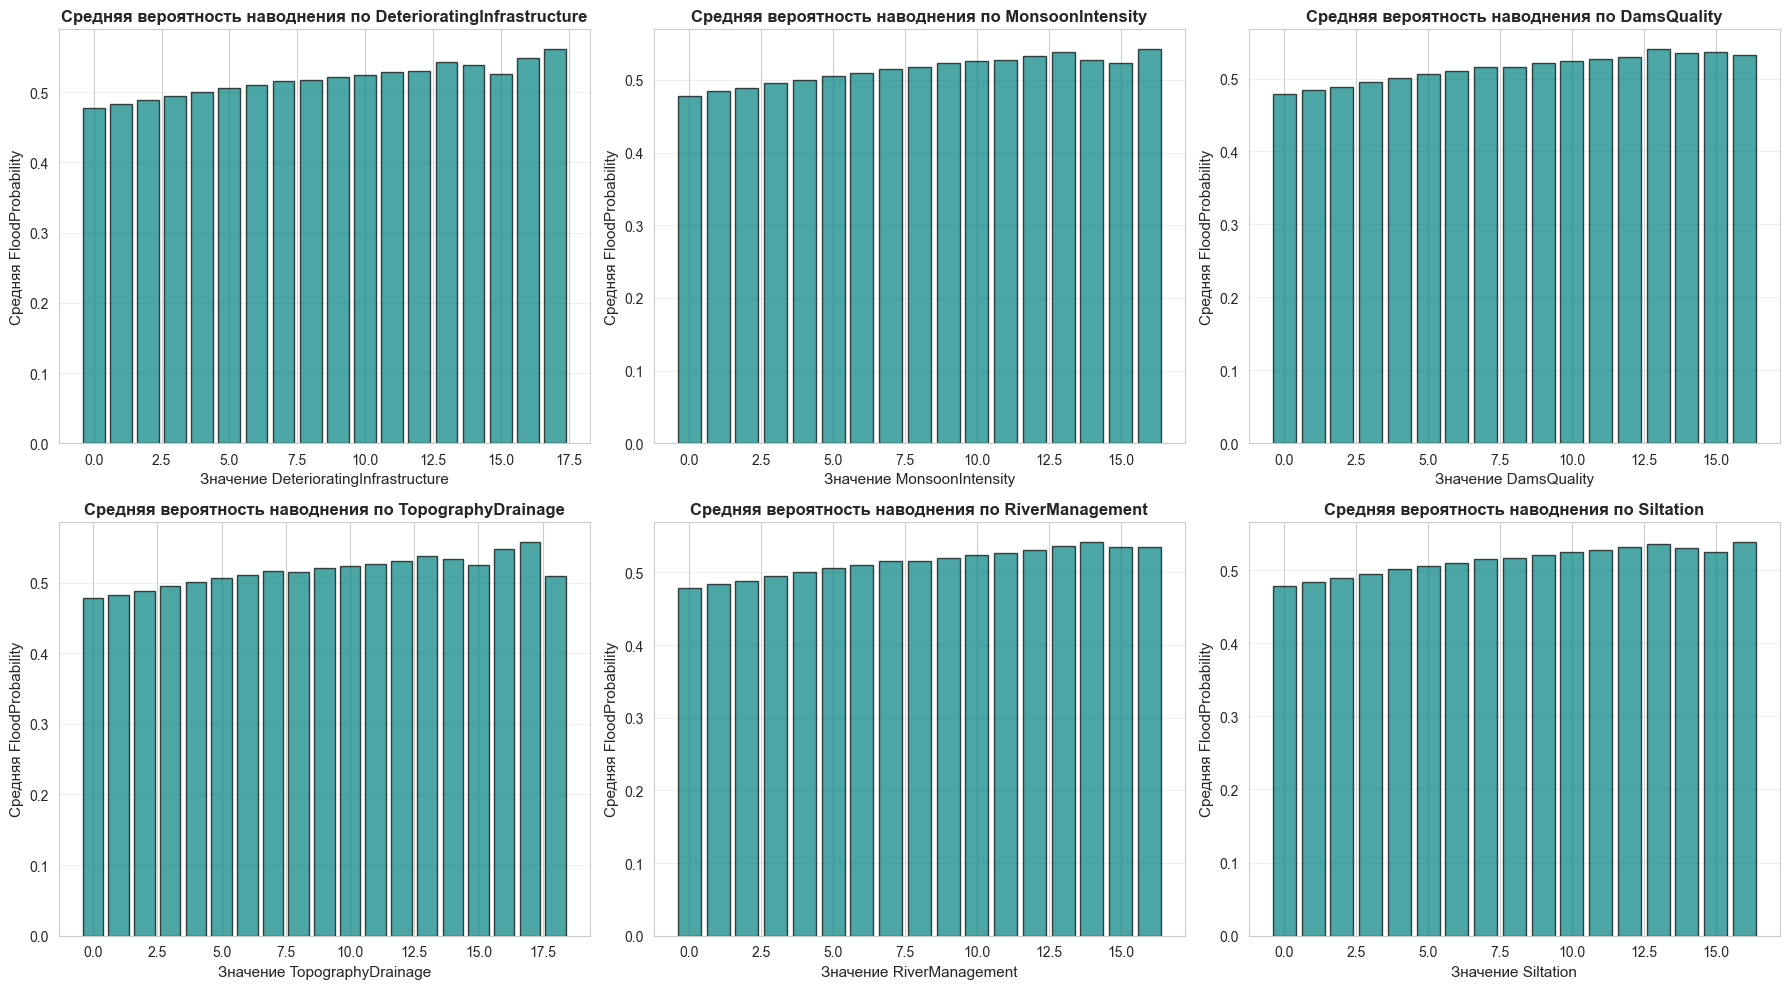

In [14]:
# Средняя вероятность наводнения для разных значений топ-признаков
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    mean_flood_by_value = train.groupby(feature)['FloodProbability'].mean().sort_index()
    
    axes[idx].bar(mean_flood_by_value.index, mean_flood_by_value.values, 
                 color='teal', alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel(f'Значение {feature}', fontsize=11)
    axes[idx].set_ylabel('Средняя FloodProbability', fontsize=11)
    axes[idx].set_title(f'Средняя вероятность наводнения по {feature}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 8. Попарные взаимосвязи топ-признаков


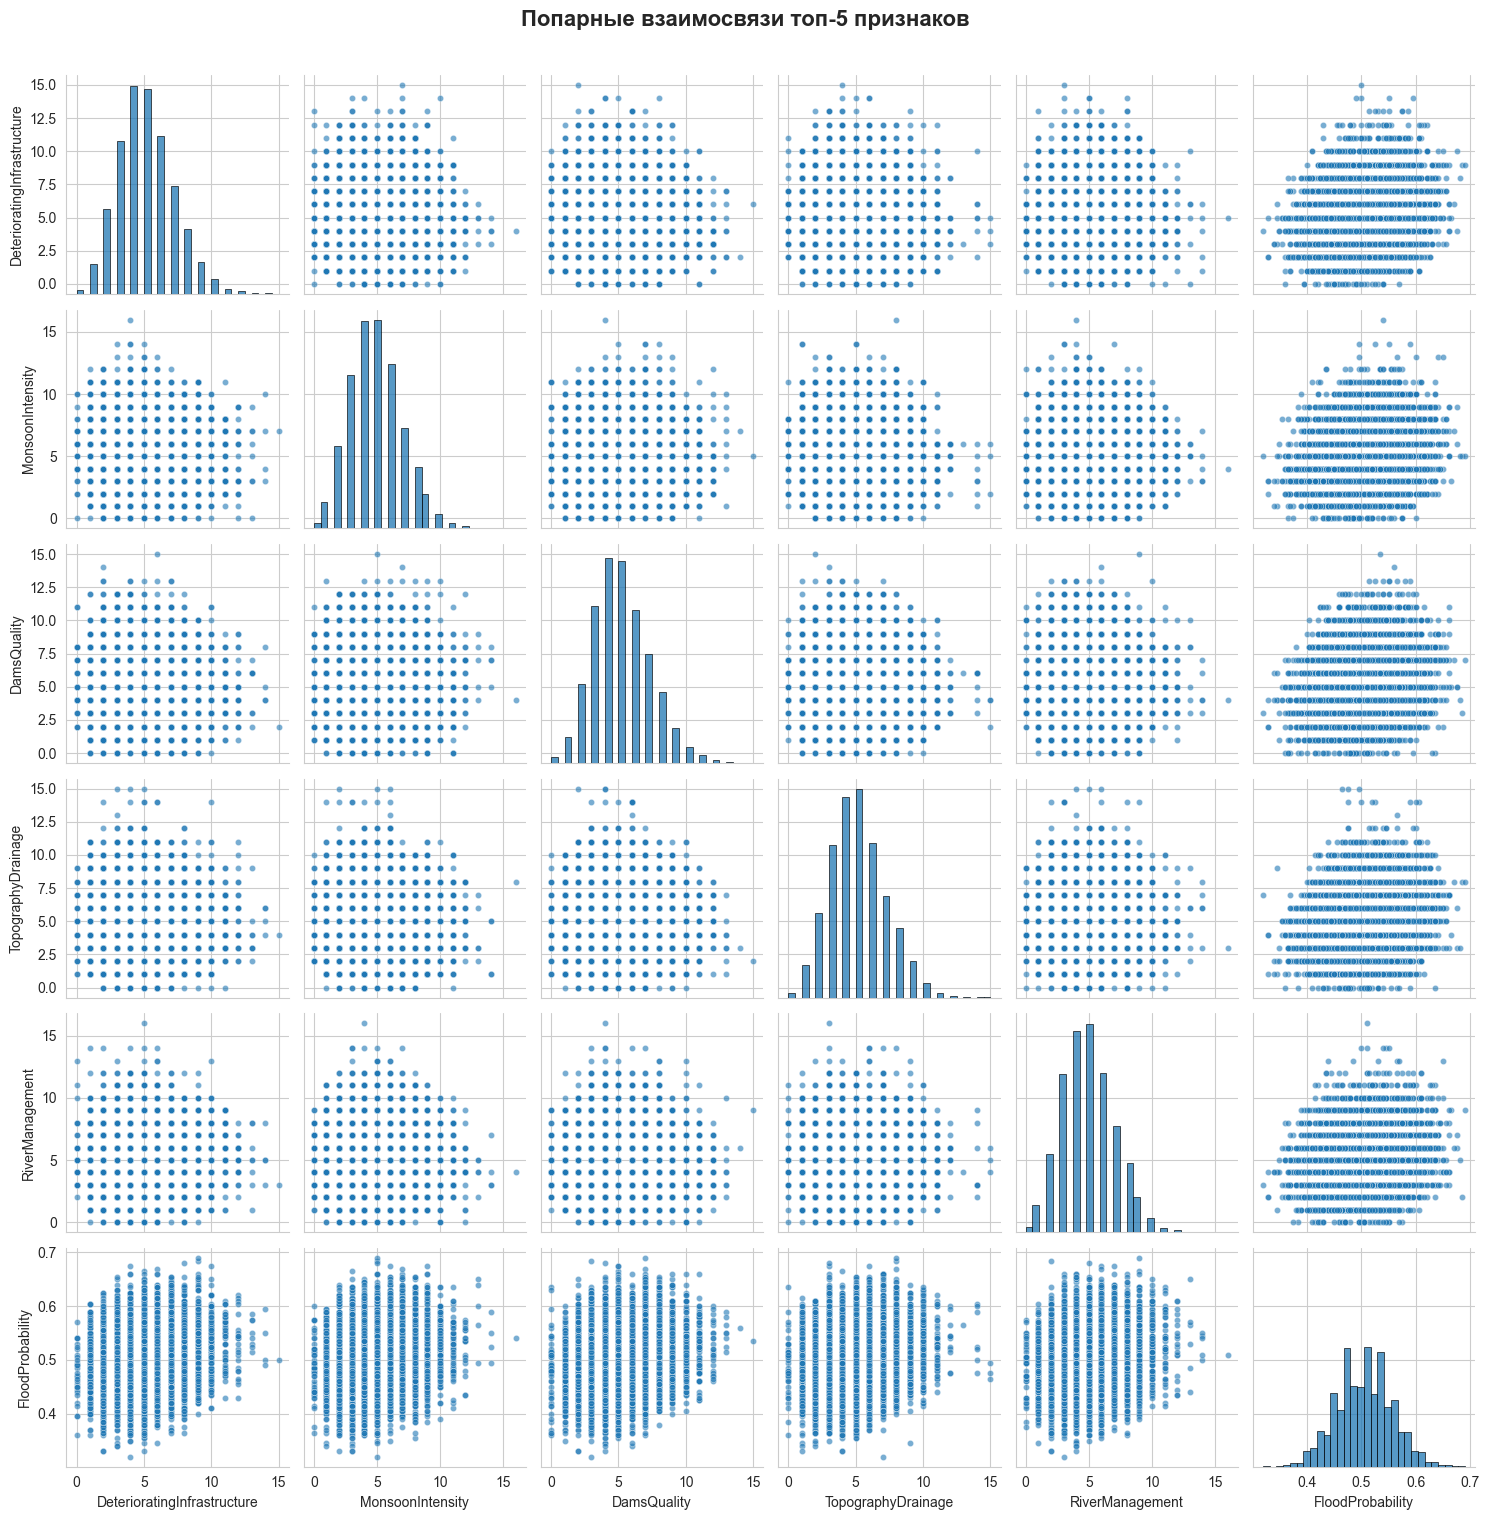

In [15]:
# Pairplot для топ-5 признаков
top_5_features = target_correlation.abs().sort_values(ascending=False).head(5).index.tolist()

# Берем подвыборку для ускорения визуализации
sample_data = train[top_5_features + ['FloodProbability']].sample(n=min(10000, len(train)), random_state=42)

pairplot = sns.pairplot(sample_data, diag_kind='hist', plot_kws={'alpha': 0.6, 's': 20}, 
                        diag_kws={'bins': 30, 'edgecolor': 'black'})
pairplot.fig.suptitle('Попарные взаимосвязи топ-5 признаков', y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Boxplot признаков по квартилям FloodProbability


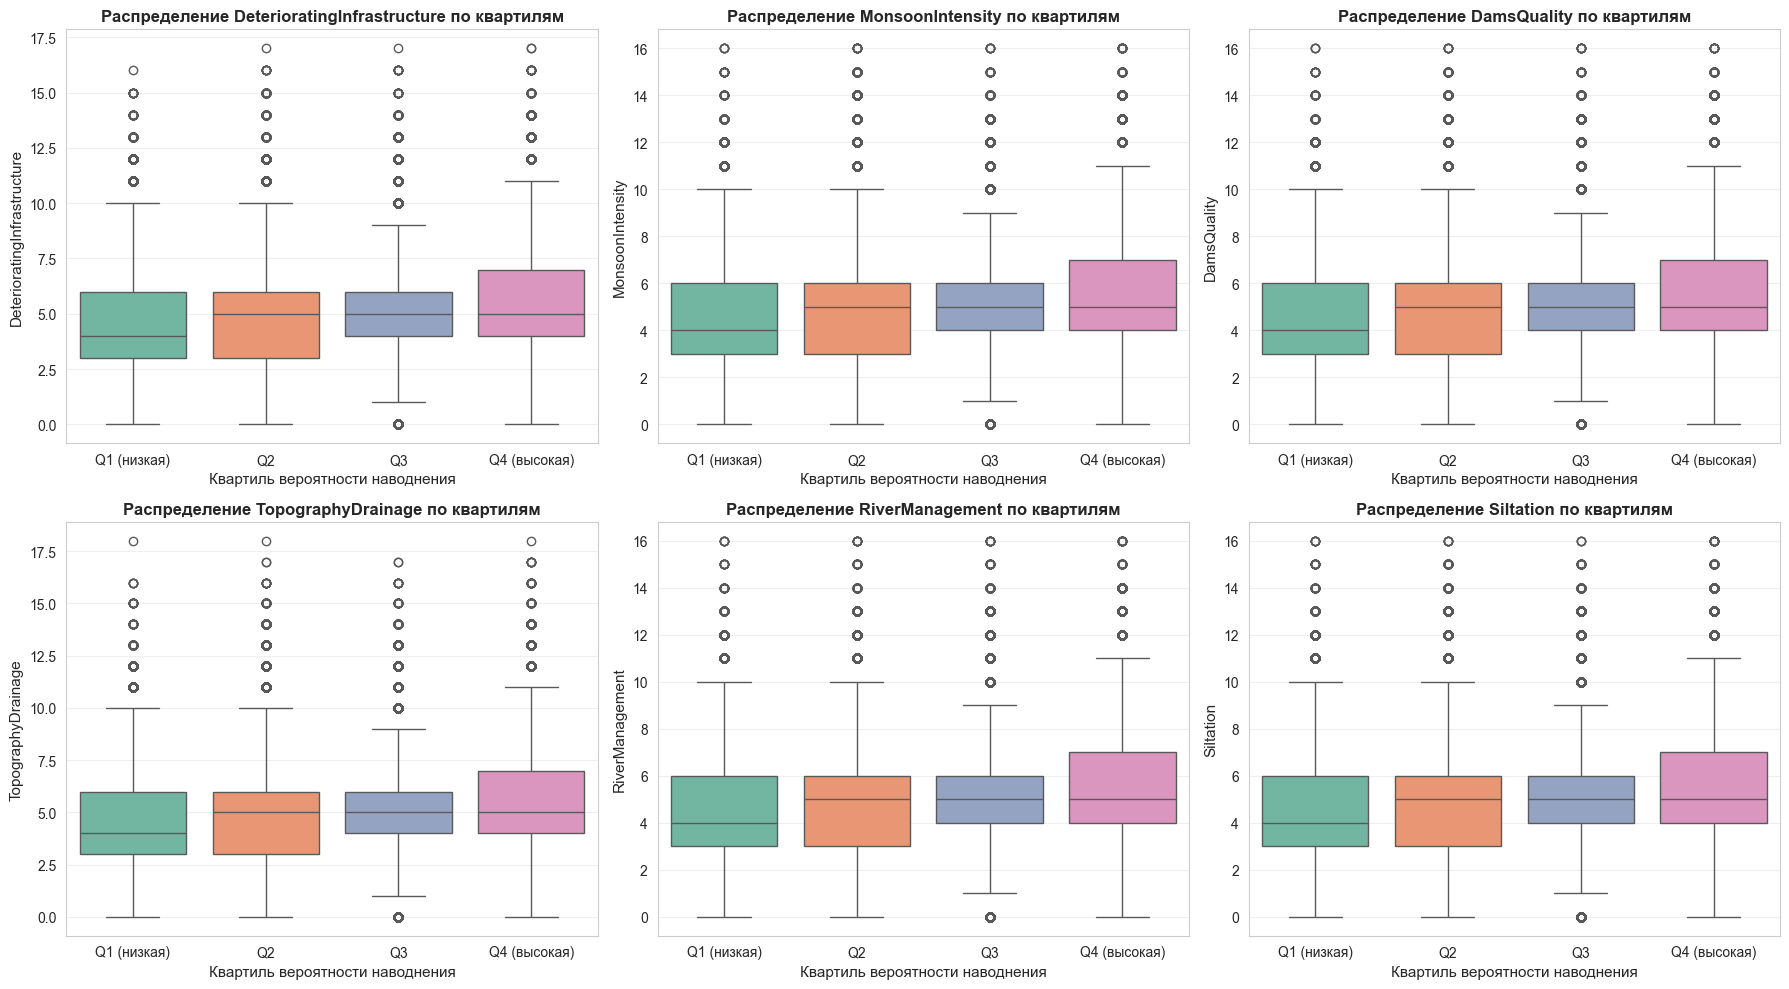

In [16]:
# Разделяем на квартили по FloodProbability
train['FloodProbability_Quartile'] = pd.qcut(train['FloodProbability'], q=4, labels=['Q1 (низкая)', 'Q2', 'Q3', 'Q4 (высокая)'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    sns.boxplot(data=train, x='FloodProbability_Quartile', y=feature, ax=axes[idx], palette='Set2')
    axes[idx].set_xlabel('Квартиль вероятности наводнения', fontsize=11)
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].set_title(f'Распределение {feature} по квартилям', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Удаляем временную колонку
train.drop('FloodProbability_Quartile', axis=1, inplace=True)


## 10. Сравнение распределений признаков в train и test


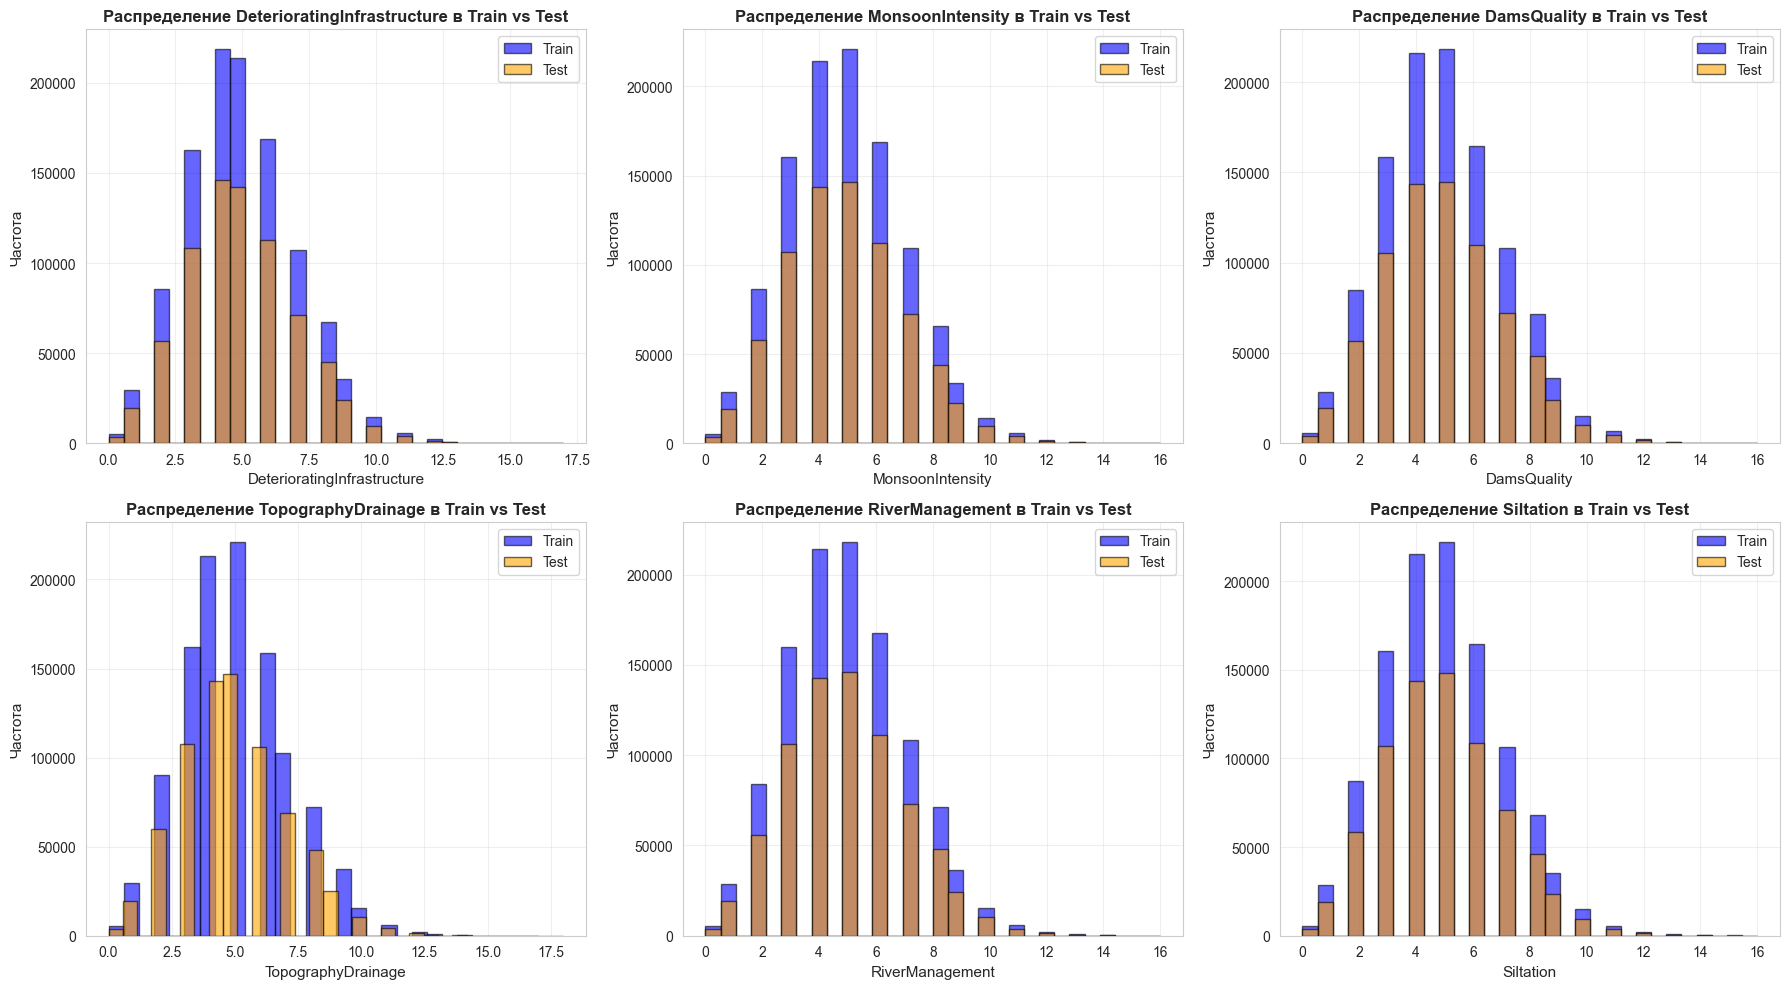

In [17]:
# Сравниваем распределения топ-6 признаков в train и test
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    axes[idx].hist(train[feature], bins=30, alpha=0.6, label='Train', color='blue', edgecolor='black')
    axes[idx].hist(test[feature], bins=30, alpha=0.6, label='Test', color='orange', edgecolor='black')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Частота', fontsize=11)
    axes[idx].set_title(f'Распределение {feature} в Train vs Test', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Анализ выбросов


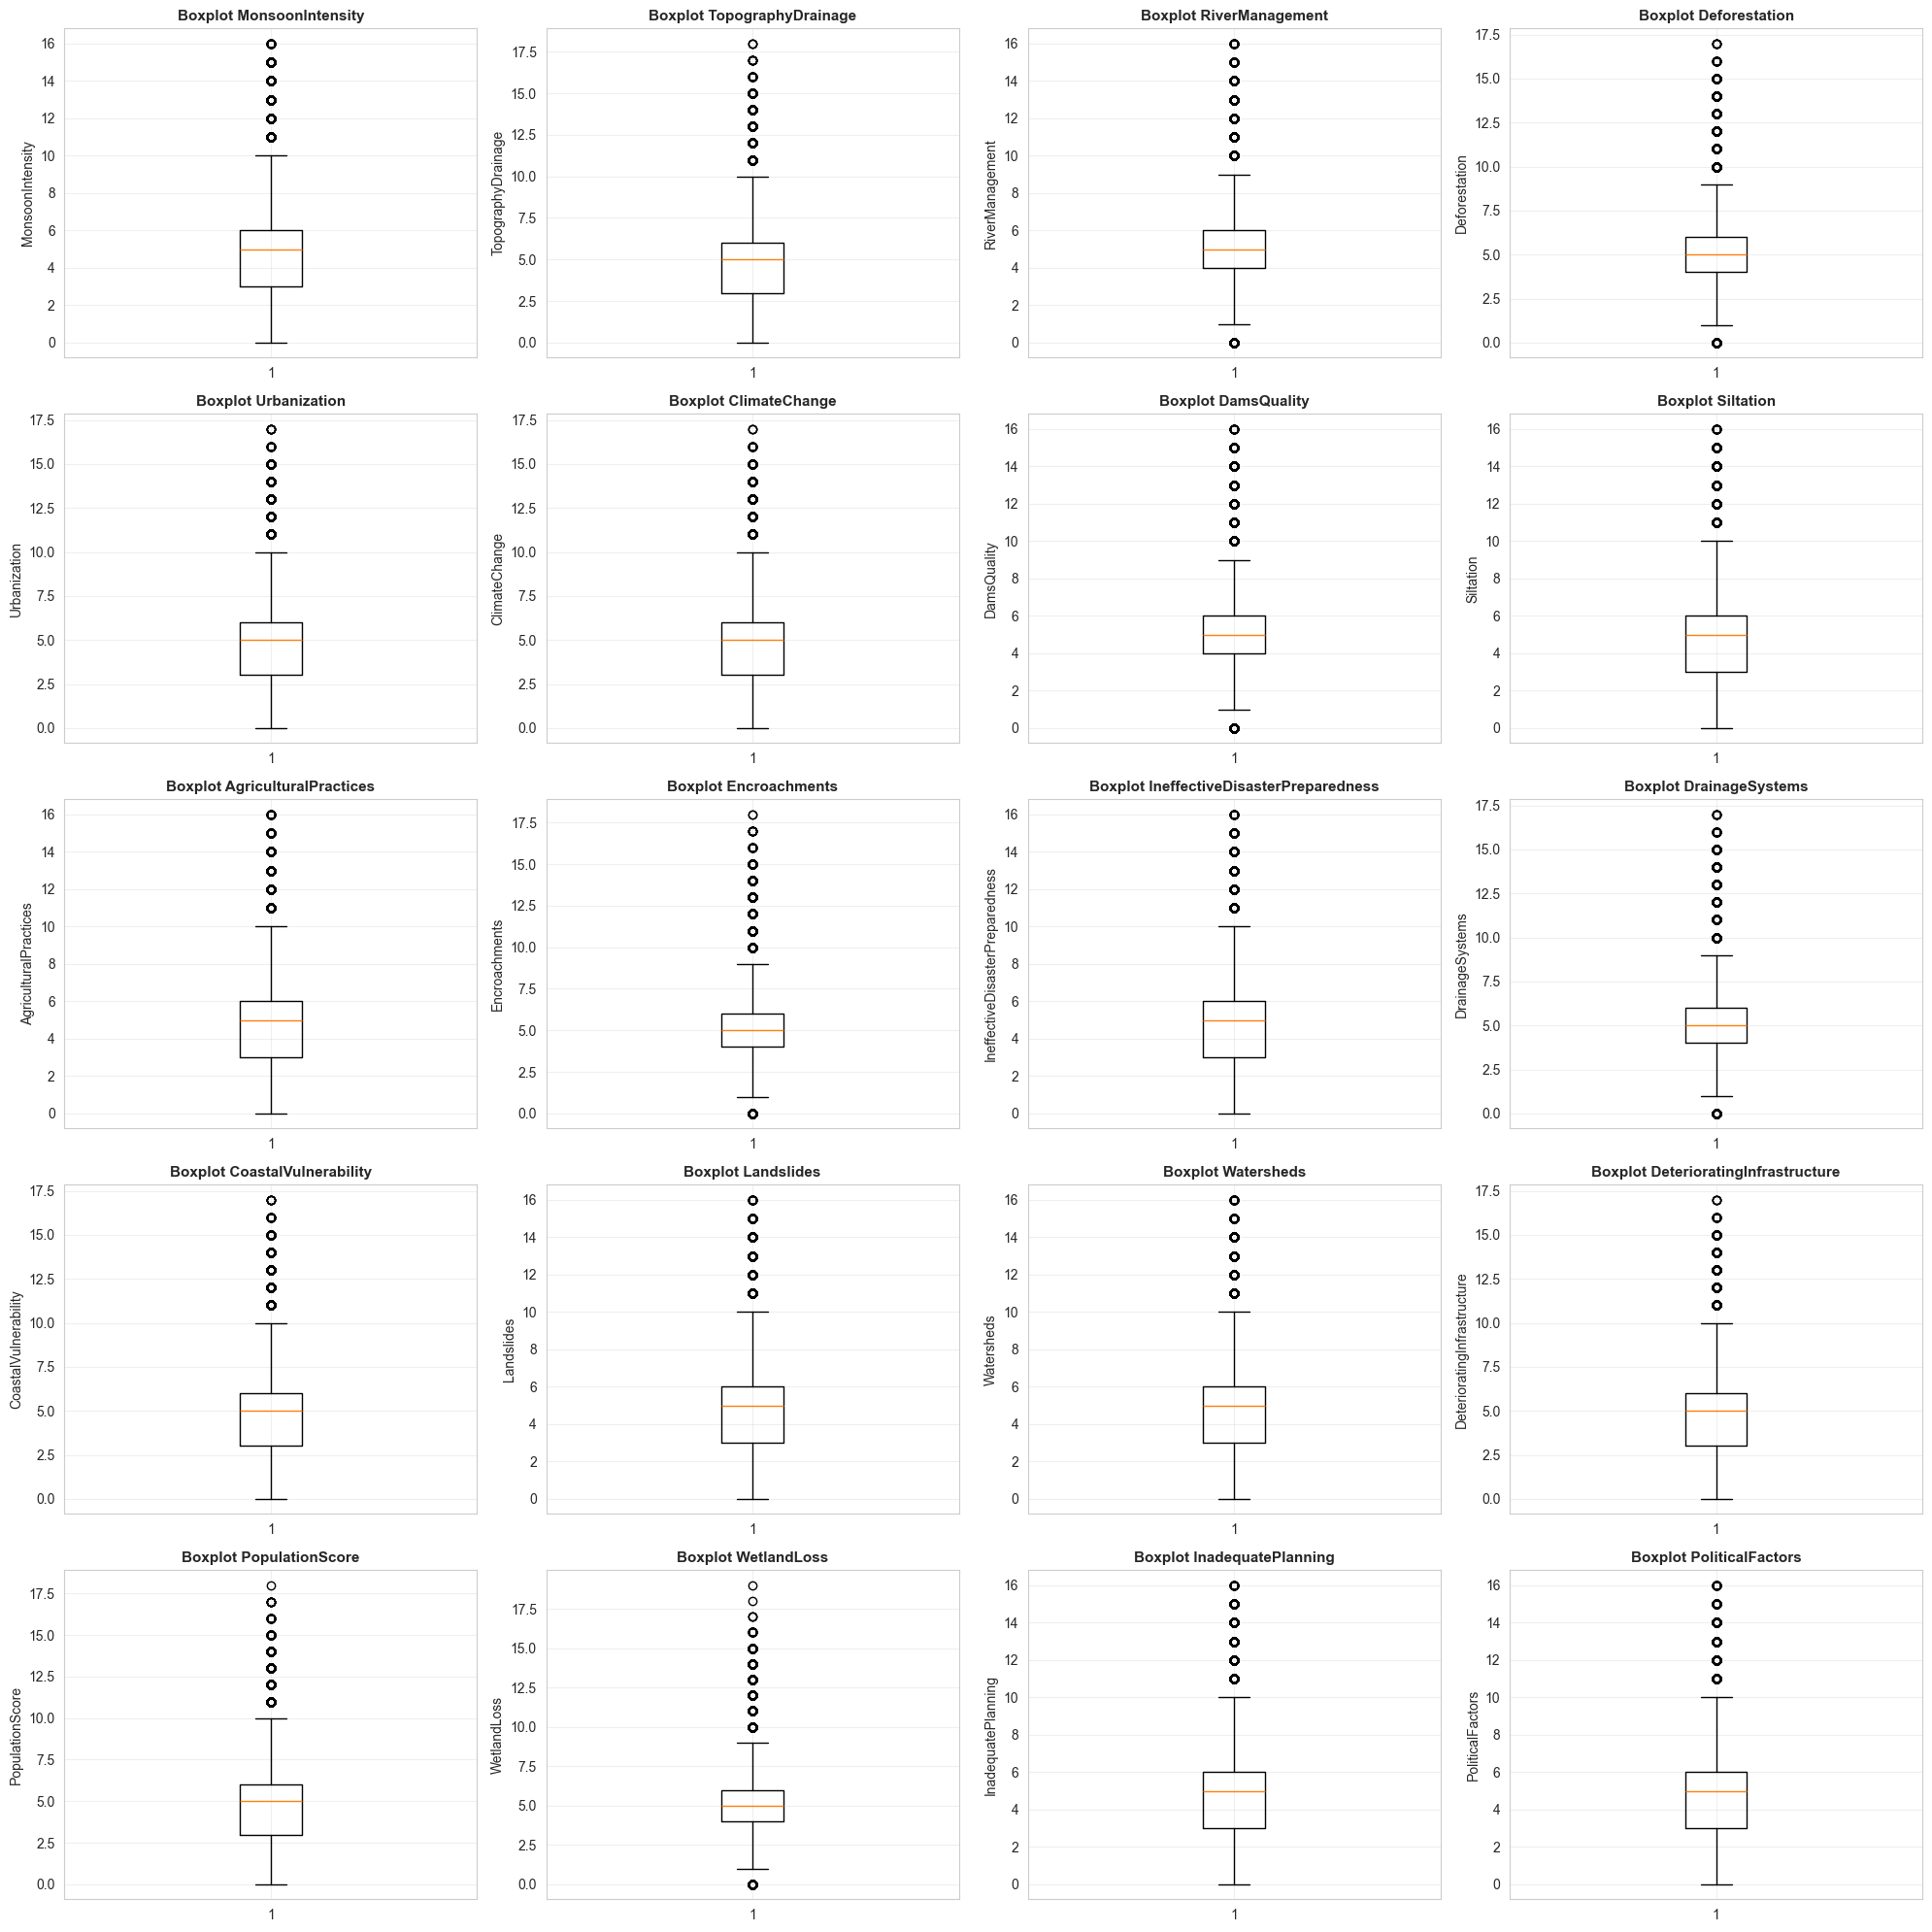

In [18]:
# Boxplot всех признаков для поиска выбросов
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for idx, feature in enumerate(features):
    axes[idx].boxplot(train[feature], vert=True)
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].set_title(f'Boxplot {feature}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
# Подсчет выбросов по методу IQR для каждого признака
outliers_summary = []

for feature in features:
    Q1 = train[feature].quantile(0.25)
    Q3 = train[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train[(train[feature] < lower_bound) | (train[feature] > upper_bound)]
    outliers_summary.append({
        'Признак': feature,
        'Количество выбросов': len(outliers),
        'Процент выбросов': len(outliers) / len(train) * 100
    })

outliers_df = pd.DataFrame(outliers_summary).sort_values('Процент выбросов', ascending=False)
print("\nВыбросы по признакам (метод IQR):")
display(outliers_df.style.background_gradient(cmap='Reds', subset=['Процент выбросов']))



Выбросы по признакам (метод IQR):


,Признак,Количество выбросов,Процент выбросов
9,Encroachments,31141,2.785528
6,DamsQuality,31097,2.781592
11,DrainageSystems,30060,2.688833
2,RiverManagement,29617,2.649207
17,WetlandLoss,29499,2.638652
3,Deforestation,28235,2.525589
12,CoastalVulnerability,10209,0.913184
19,PoliticalFactors,9707,0.868280
1,TopographyDrainage,9575,0.856473
18,InadequatePlanning,9299,0.831785


## 12. Резюме анализа


In [20]:
print("=" * 80)
print("РЕЗЮМЕ АНАЛИЗА ДАННЫХ")
print("=" * 80)
print(f"\n📊 РАЗМЕР ДАННЫХ:")
print(f"  • Train: {train.shape[0]:,} строк, {train.shape[1]} столбцов")
print(f"  • Test: {test.shape[0]:,} строк, {test.shape[1]} столбцов")

print(f"\n🎯 ЦЕЛЕВАЯ ПЕРЕМЕННАЯ (FloodProbability):")
print(f"  • Диапазон: [{train['FloodProbability'].min():.4f}, {train['FloodProbability'].max():.4f}]")
print(f"  • Среднее: {train['FloodProbability'].mean():.4f}")
print(f"  • Стандартное отклонение: {train['FloodProbability'].std():.4f}")

print(f"\n🔍 ПРИЗНАКИ:")
print(f"  • Количество признаков: {len(features)}")
print(f"  • Пропущенные значения: {'Нет' if train[features].isnull().sum().sum() == 0 else 'Есть'}")

print(f"\n🔗 ТОП-5 ПРИЗНАКОВ ПО КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:")
for i, (feat, corr) in enumerate(target_correlation.head(5).items(), 1):
    print(f"  {i}. {feat}: {corr:.4f}")

print(f"\n⚠️  ВЫБРОСЫ:")
top_outliers = outliers_df.head(3)
for _, row in top_outliers.iterrows():
    print(f"  • {row['Признак']}: {row['Процент выбросов']:.2f}%")

print("\n" + "=" * 80)


РЕЗЮМЕ АНАЛИЗА ДАННЫХ

📊 РАЗМЕР ДАННЫХ:
  • Train: 1,117,957 строк, 22 столбцов
  • Test: 745,305 строк, 21 столбцов

🎯 ЦЕЛЕВАЯ ПЕРЕМЕННАЯ (FloodProbability):
  • Диапазон: [0.2850, 0.7250]
  • Среднее: 0.5045
  • Стандартное отклонение: 0.0510

🔍 ПРИЗНАКИ:
  • Количество признаков: 20
  • Пропущенные значения: Нет

🔗 ТОП-5 ПРИЗНАКОВ ПО КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
  1. DeterioratingInfrastructure: 0.1900
  2. MonsoonIntensity: 0.1891
  3. DamsQuality: 0.1880
  4. TopographyDrainage: 0.1876
  5. RiverManagement: 0.1871

⚠️  ВЫБРОСЫ:
  • Encroachments: 2.79%
  • DamsQuality: 2.78%
  • DrainageSystems: 2.69%

